<a href="https://colab.research.google.com/github/AbdulkaderKharrat/AbdulkaderKharrat/blob/main/diamonds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/diamonds.csv')
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [ ]:
df.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [ ]:
df.isnull()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
53935,False,False,False,False,False,False,False,False,False,False,False
53936,False,False,False,False,False,False,False,False,False,False,False
53937,False,False,False,False,False,False,False,False,False,False,False
53938,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.duplicated().sum

<bound method Series.sum of 0        False
1        False
2        False
3        False
4        False
         ...  
53935    False
53936    False
53937    False
53938    False
53939    False
Length: 53940, dtype: bool>

In [ ]:
df['cut'].value_counts()

,count
cut,
Ideal,21551
Premium,13791
Very Good,12082
Good,4906
Fair,1610


In [ ]:
df['color'].value_counts()

,count
color,
G,11292
E,9797
F,9542
H,8304
D,6775
I,5422
J,2808


In [ ]:
df['clarity'].value_counts()

,count
clarity,
SI1,13065
VS2,12258
SI2,9194
VS1,8171
VVS2,5066
VVS1,3655
IF,1790
I1,741


In [ ]:
numerical_features = df.select_dtypes(include='number')
numerical_features.columns

Index(['Unnamed: 0', 'carat', 'depth', 'table', 'price', 'x', 'y', 'z'], dtype='object')

In [ ]:
categorical_features = df.select_dtypes(include='object')
categorical_features.columns

Index(['cut', 'color', 'clarity'], dtype='object')

In [ ]:
df.drop('Unnamed: 0',axis=1,inplace=True)

In [ ]:
# Calculate aspect ratio
numerical_features['aspect_ratio'] = numerical_features['x'] / numerical_features['y']
numerical_features['xy_area'] = numerical_features['x'] * numerical_features['y']  # Area based on length and width
numerical_features

,Unnamed: 0,carat,depth,table,price,x,y,z,aspect_ratio,xy_area
0,1,0.23,61.5,55.0,326,3.95,3.98,2.43,0.992462,15.7210
1,2,0.21,59.8,61.0,326,3.89,3.84,2.31,1.013021,14.9376
2,3,0.23,56.9,65.0,327,4.05,4.07,2.31,0.995086,16.4835
3,4,0.29,62.4,58.0,334,4.20,4.23,2.63,0.992908,17.7660
4,5,0.31,63.3,58.0,335,4.34,4.35,2.75,0.997701,18.8790
...,...,...,...,...,...,...,...,...,...,...
53935,53936,0.72,60.8,57.0,2757,5.75,5.76,3.50,0.998264,33.1200
53936,53937,0.72,63.1,55.0,2757,5.69,5.75,3.61,0.989565,32.7175
53937,53938,0.70,62.8,60.0,2757,5.66,5.68,3.56,0.996479,32.1488
53938,53939,0.86,61.0,58.0,2757,6.15,6.12,3.74,1.004902,37.6380


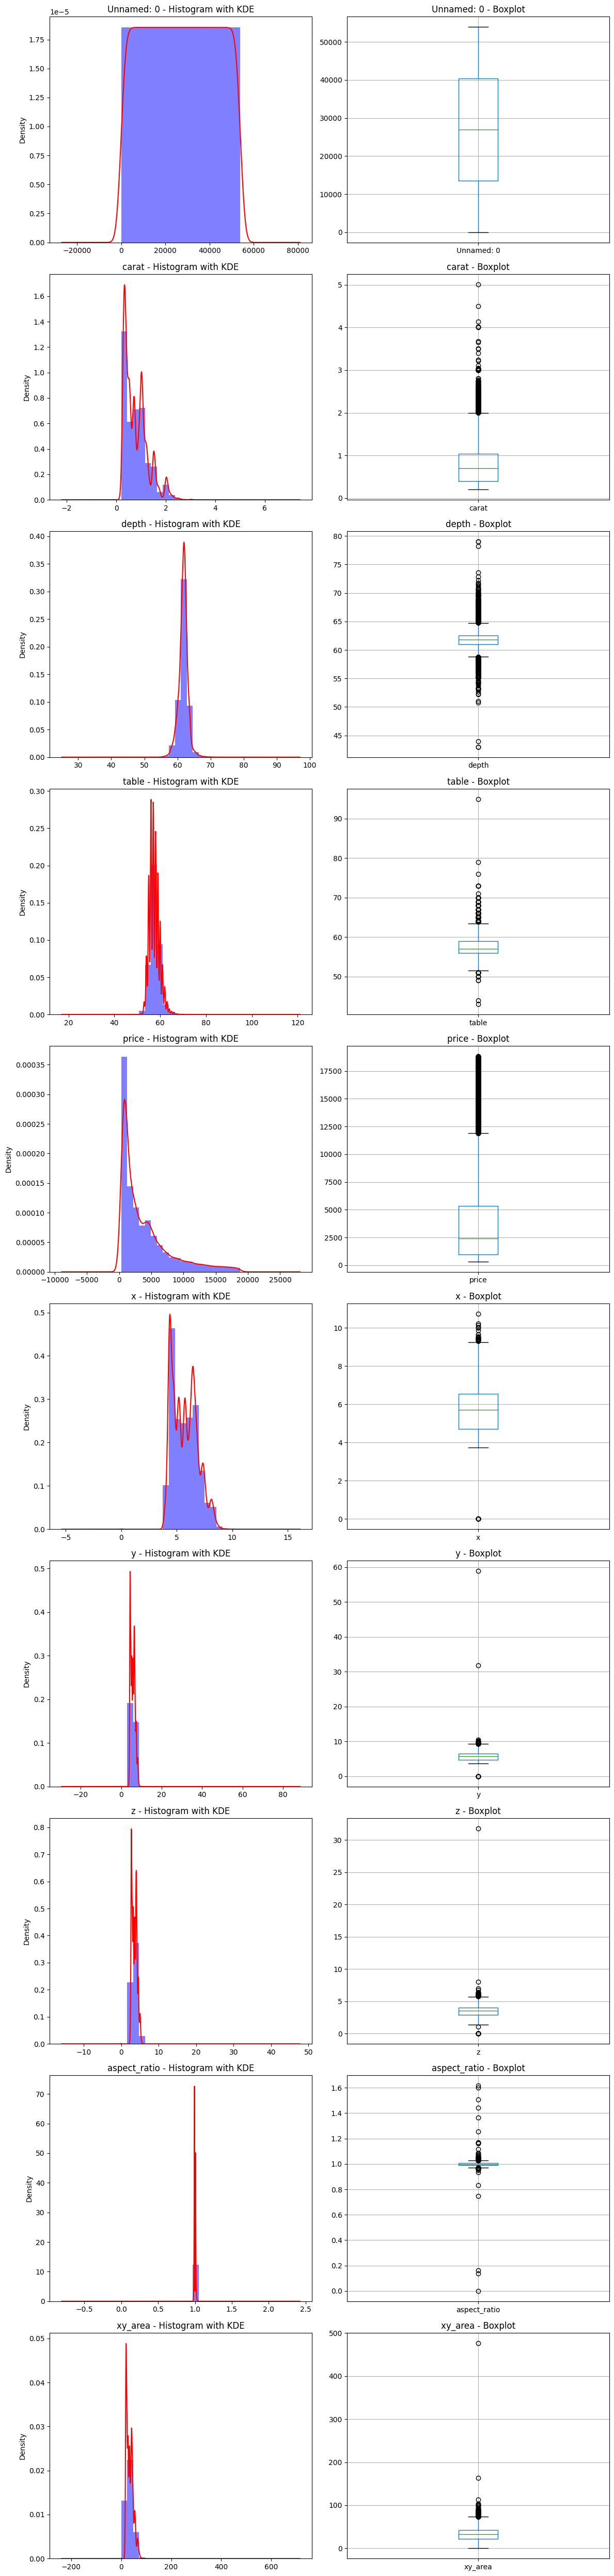

In [ ]:
# Plotting Histogram with KDE and Boxplot for each numerical feature
fig, axes = plt.subplots(len(numerical_features.columns), 2, figsize=(12, 5 * len(numerical_features.columns)))

for i, col in enumerate(numerical_features.columns):
    # Histogram with KDE
    numerical_features[col].plot(kind='hist', density=True, ax=axes[i, 0], bins=20, alpha=0.5, color='blue')
    numerical_features[col].plot(kind='kde', ax=axes[i, 0], color='red')
    axes[i, 0].set_title(f'{col} - Histogram with KDE')

    # Boxplot
    numerical_features.boxplot(column=col, ax=axes[i, 1])
    axes[i, 1].set_title(f'{col} - Boxplot')

plt.tight_layout()
plt.show()

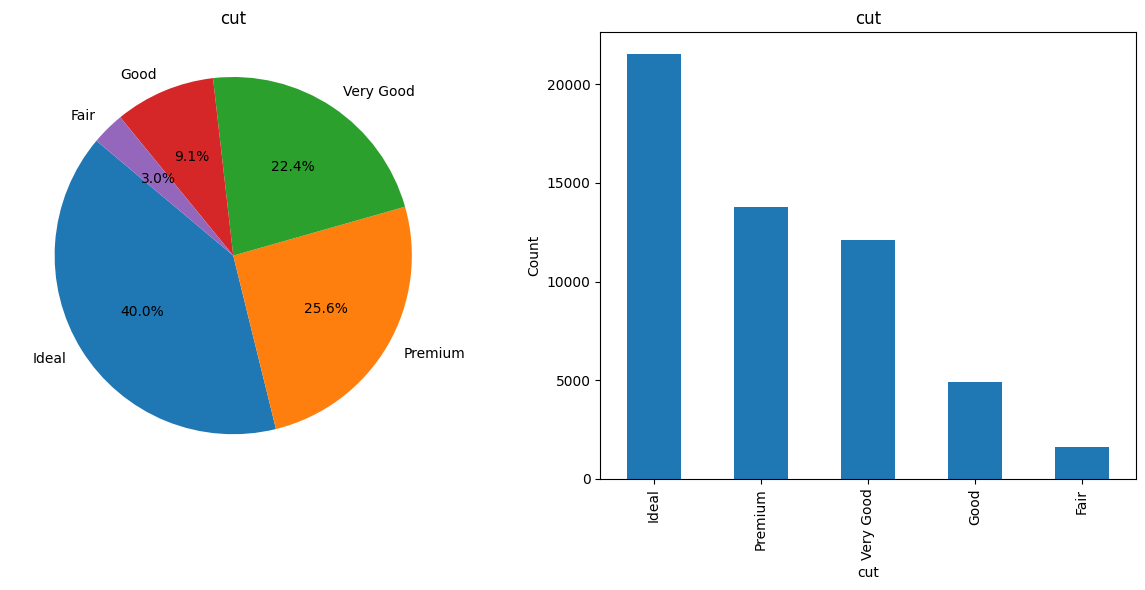

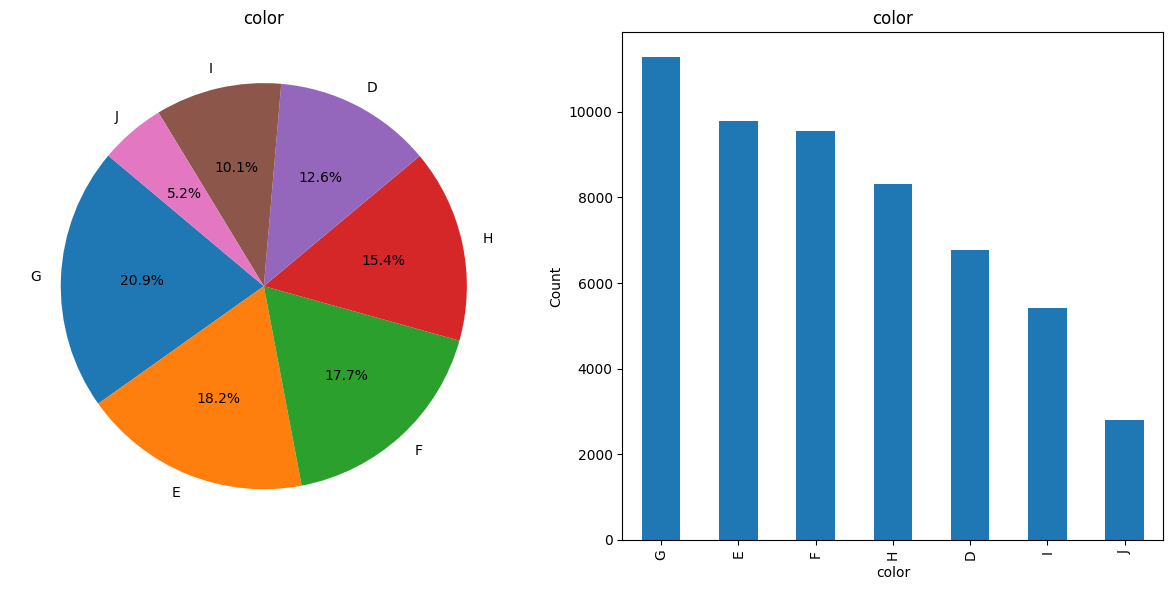

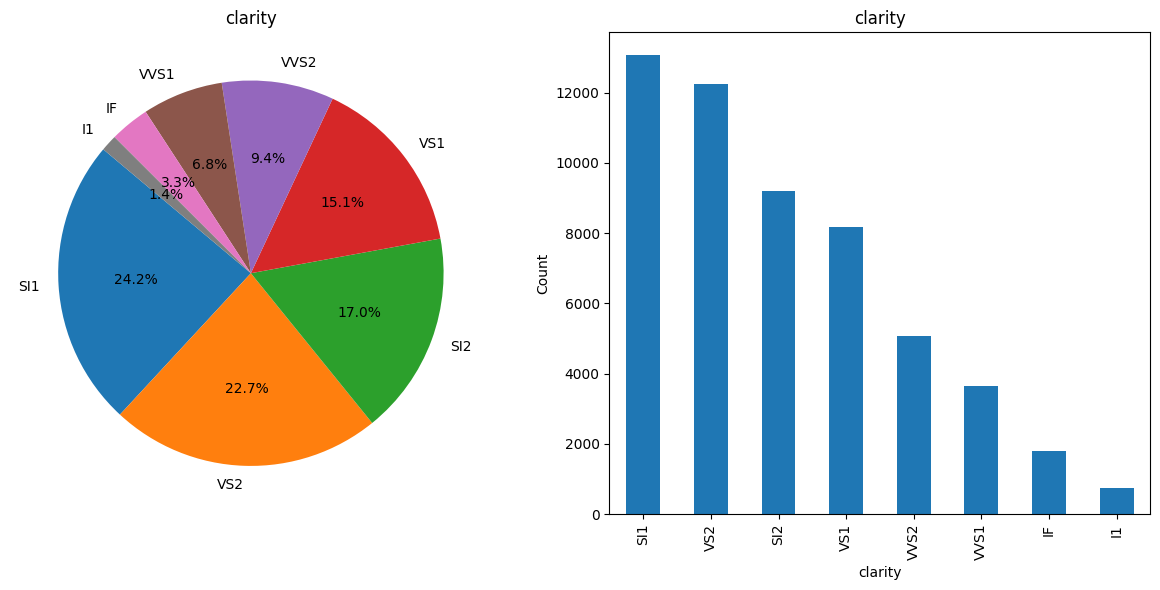

In [ ]:
for i in categorical_features.columns:
  counts = categorical_features[i].value_counts()

  # Plotting
  fig, axes = plt.subplots(1, 2, figsize=(12, 6))

  # Pie chart
  axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140)
  axes[0].set_title(i)

  # Bar chart
  counts.plot(kind='bar', ax=axes[1])
  axes[1].set_title(i)
  axes[1].set_ylabel('Count')
  axes[1].set_xlabel(i)

  plt.tight_layout()
  plt.show()

In [ ]:
# Import label encoder
from sklearn import preprocessing
# label_encoder object knows
# how to understand word labels.
label_encoder = preprocessing.LabelEncoder()

# Encode labels in columns.
for i in range(categorical_features.shape[1]):
  categorical_features.iloc[:,i] = label_encoder.fit_transform(categorical_features.iloc[:,i])

In [ ]:
categorical_features.head()

,cut,color,clarity
0,2,1,3
1,3,1,2
2,1,1,4
3,3,5,5
4,1,6,3


In [ ]:
# ... (previous code) ...

from sklearn.preprocessing import MinMaxScaler

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Columns to scale
scale_cols = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']

# Assuming you have a separate training dataset (e.g., df_train)
# Fit and transform on the training data
numerical_features[scale_cols] = scaler.fit_transform(numerical_features[scale_cols])

# Transform the original data (or a test dataset if you have one)
numerical_features[scale_cols] = scaler.transform(numerical_features[scale_cols])

# ... (rest of the code) ...

In [ ]:
# concatenating df_num_features and df_cat_features along columns
df_all_features = pd.concat([numerical_features, categorical_features], axis=1)
df_all_features.head()

,Unnamed: 0,carat,depth,table,price,x,y,z,aspect_ratio,xy_area,cut,color,clarity
0,1,-0.040283,-1.180170,-0.822485,-0.017624,0.034244,0.001147,0.002403,0.992462,15.7210,2,1,3
1,2,-0.041148,-1.181481,-0.820266,-0.017624,0.033724,0.001107,0.002284,1.013021,14.9376,3,1,2
2,3,-0.040283,-1.183719,-0.818787,-0.017624,0.035111,0.001173,0.002284,0.995086,16.4835,1,1,4
3,4,-0.037690,-1.179475,-0.821376,-0.017624,0.036412,0.001219,0.002601,0.992908,17.7660,3,5,5
4,5,-0.036826,-1.178781,-0.821376,-0.017624,0.037625,0.001254,0.002719,0.997701,18.8790,1,6,3


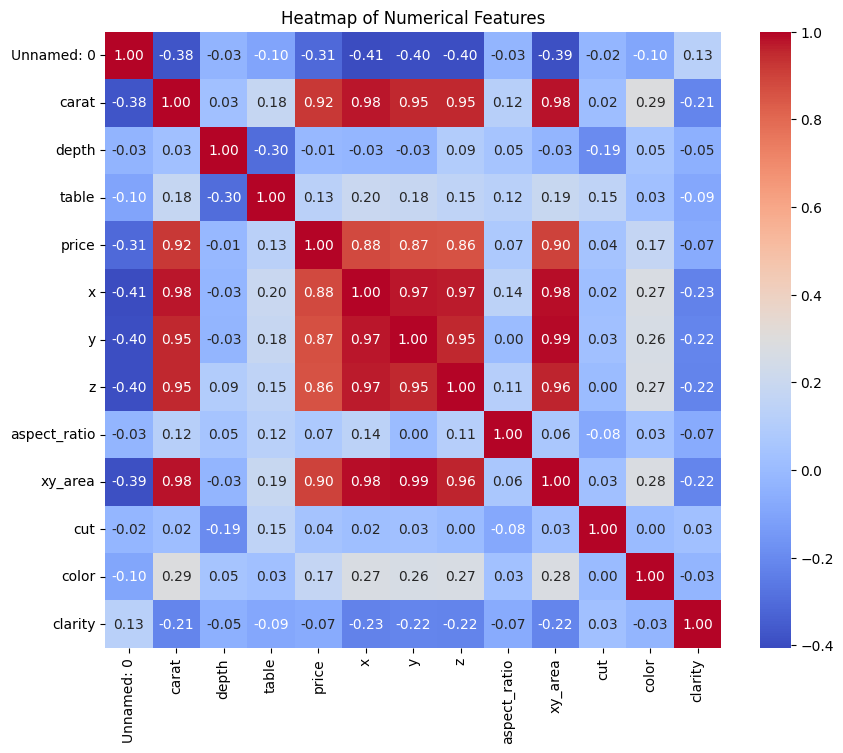

In [ ]:
corr = df_all_features.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Heatmap of Numerical Features')
plt.show()

In [ ]:
X = df_all_features.drop('price', axis=1)
y = df_all_features['price']

In [ ]:
X.head()

,Unnamed: 0,carat,depth,table,x,y,z,aspect_ratio,xy_area,cut,color,clarity
0,1,-0.040283,-1.180170,-0.822485,0.034244,0.001147,0.002403,0.992462,15.7210,2,1,3
1,2,-0.041148,-1.181481,-0.820266,0.033724,0.001107,0.002284,1.013021,14.9376,3,1,2
2,3,-0.040283,-1.183719,-0.818787,0.035111,0.001173,0.002284,0.995086,16.4835,1,1,4
3,4,-0.037690,-1.179475,-0.821376,0.036412,0.001219,0.002601,0.992908,17.7660,3,5,5
4,5,-0.036826,-1.178781,-0.821376,0.037625,0.001254,0.002719,0.997701,18.8790,1,6,3


In [ ]:
X.isnull().sum()

,0
Unnamed: 0,0
carat,0
depth,0
table,0
x,0
y,0
z,0
aspect_ratio,7
xy_area,0
cut,0


In [ ]:
X.fillna(X.median(), inplace=True)

<ipython-input-24-eed314ce733d>:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X.fillna(X.median(), inplace=True)


In [ ]:
X.duplicated().sum()

0

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Encode the categorical columns directly in your test data (df_test_all_features)
X_train["cut"] = label_encoder.fit_transform(X_train["cut"])
X_train["color"] = label_encoder.fit_transform(X_train["color"])
X_train["clarity"] = label_encoder.fit_transform(X_train["clarity"])
X_test["cut"] = label_encoder.fit_transform(X_test["cut"])
X_test["color"] = label_encoder.fit_transform(X_test["color"])
X_test["clarity"] = label_encoder.fit_transform(X_test["clarity"])

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# Create a linear regression model
lr_model = LinearRegression()

# Fit the model to the training data
lr_model.fit(X_train, y_train)
y_pred_test = lr_model.predict(X_test)
print('Score for training set:',lr_model.score(X_train, y_train))
print('Score for testing set:',lr_model.score(X_test, y_test))

print("Linear Regression")
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred_test))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred_test))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred_test)))

Score for training set: 0.8886490329401618
Score for testing set: 0.8910185789480852
Linear Regression
Mean Absolute Error: 2.467448417088313e-06
Mean Squared Error: 1.4799858960733658e-11
Root Mean Squared Error: 3.847058481584814e-06


In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt_regressor = DecisionTreeRegressor(random_state = 40)
dt_regressor.fit(X_train,y_train)
y_dt_pred = dt_regressor.predict(X_test)

# score
accuracy_train=dt_regressor.score(X_train,y_train)
accuracy_test=dt_regressor.score(X_test,y_test)
print("Accuracy train of Decision Tree model is:",accuracy_train)
print("Accuracy test of Decision Tree model is:",accuracy_test)
print("Decision Tree")
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_dt_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_dt_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_dt_pred)))

Accuracy train of Decision Tree model is: 0.9999992136038031
Accuracy test of Decision Tree model is: 0.999941626259214
Decision Tree
Mean Absolute Error: 1.4881136646724954e-08
Mean Squared Error: 7.927251473736042e-15
Root Mean Squared Error: 8.903511371215316e-08


In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=6)
knn.fit(X_train, y_train)
ans4 = knn.predict(X_test)
# score
accuracy_knn_train=knn.score(X_train,y_train)
accuracy_knn_test=knn.score(X_test,y_test)
print("Accuracy train of KNN model is:",accuracy_knn_train)
print("Accuracy test of KNN model is:",accuracy_knn_test)
print("KNN Model")
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, ans4))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, ans4))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, ans4)))

In [ ]:
# Importing necessary libraries
from sklearn.ensemble import RandomForestRegressor
# Evaluating the model
from sklearn.metrics import mean_squared_error, r2_score
from sklearn import metrics

# Initialize a Random Forest Regression
rf_regressor = RandomForestRegressor(n_estimators=20, random_state=42, oob_score=True)
# Train the regressor
rf_regressor.fit(X_train, y_train)
# Predict on the testing set
y_pred = rf_regressor.predict(X_test)

# Access the OOB Score
oob_score = rf_regressor.oob_score_
print(f'Out-of-Bag Score: {oob_score}')
# Calculate accuracy
accuracy_tr = rf_regressor.score(X_train, y_train)
accuracy_te = rf_regressor.score(X_test, y_test)
print(f"Accuracy of Random Forest on Our Training dataset: {accuracy_tr * 100:.2f}%")
print(f"Accuracy of Random Forest on Our Testing dataset: {accuracy_te * 100:.2f}%")
# Evaluating the model
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {np.sqrt(mse)}')

r2 = r2_score(y_test, y_pred)
print(f'R-squared: {r2}')

In [ ]:
diamond_test_dataframe = pd.read_csv('/content/diamonds.csv')
df_test = diamond_test_dataframe.copy()
df_test.head(4)

In [ ]:
ID = df_test['Unnamed: 0']
ID.head()

In [ ]:
df_test.drop('Unnamed: 0',axis=1,inplace=True)

In [ ]:
df_test.head()

In [ ]:
df_test_numerical_features = df_test.select_dtypes(include='number')
df_test_numerical_features.columns

In [ ]:
df_test_categorical_features = df_test.select_dtypes(include='object')
df_test_categorical_features.columns

In [ ]:
# Import label encoder
from sklearn import preprocessing
# label_encoder object knows
# how to understand word labels.
label_encoder = preprocessing.LabelEncoder()

# Encode labels in columns.
for i in range(df_test_categorical_features.shape[1]):
  df_test_categorical_features.iloc[:,i] = label_encoder.fit_transform(df_test_categorical_features.iloc[:,i])

In [ ]:
df_test_categorical_features

In [ ]:
# Calculate aspect ratio
df_test_numerical_features['aspect_ratio'] = df_test_numerical_features['x'] / df_test_numerical_features['y']
df_test_numerical_features['xy_area'] = df_test_numerical_features['x'] * df_test_numerical_features['y']  # Area based on length and width
df_test_numerical_features

In [ ]:
df_test_numerical_features.drop(['x','y','z','table'],axis=1,inplace=True)
df_test_numerical_features

In [ ]:
# concatenating df_num_features and df_cat_features along columns
df_test_all_features = pd.concat([df_test_numerical_features, df_test_categorical_features], axis=1)
df_test_all_features.head()

In [ ]:
# from sklearn.preprocessing import StandardScaler
# from sklearn import preprocessing
# from sklearn.preprocessing import StandardScaler
# # Using MinMaxScaler
# scaler = preprocessing.StandardScaler()
# # here we pass X_test as parameter
# d = scaler.fit_transform(df_test_all_features)
# df_test_all_features = pd.DataFrame(d, columns=df_test_all_features.columns)
# df_test_all_features.head()

In [ ]:
df_test_all_features.isna().sum()

In [ ]:
# df_test_all_features.fillna(X.mean(), inplace=True)

# Alternatively, fill only specific columns
df_test_all_features['aspect_ratio'].fillna(df_test_all_features['aspect_ratio'].mean(), inplace=True)  # Fill only 'carat' column

In [ ]:
df_test_all_features.isna().sum()

In [ ]:
df_test_all_features.info()

In [ ]:
corr = df_test_all_features.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Heatmap of Numerical Features')
plt.show()

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=6)
knn.fit(X_test, y_test)
ans4 = knn.predict(X_test)
# score
accuracy_knn_train=knn.score(X_test,y_test)
accuracy_knn_test=knn.score(X_test,y_test)
print("Accuracy train of KNN model is:",accuracy_knn_test)
print("Accuracy test of KNN model is:",accuracy_knn_test)
print("KNN Model")
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, ans4))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, ans4))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, ans4)))

In [ ]:
#random forest
# Importing necessary libraries
from sklearn.ensemble import RandomForestRegressor
# Evaluating the model
from sklearn.metrics import mean_squared_error, r2_score
from sklearn import metrics

# Initialize a Random Forest Regression
rf_regressor = RandomForestRegressor(n_estimators=20, random_state=42, oob_score=True)
# Train the regressor
rf_regressor.fit(X_train, y_train)
# Predict on the testing set
y_pred = rf_regressor.predict(X_test)

# Access the OOB Score
oob_score = rf_regressor.oob_score_
print(f'Out-of-Bag Score: {oob_score}')
# Calculate accuracy
accuracy_tr = rf_regressor.score(X_train, y_train)
accuracy_te = rf_regressor.score(X_test, y_test)
print(f"Accuracy of Random Forest on Our Training dataset: {accuracy_tr * 100:.2f}%")
print(f"Accuracy of Random Forest on Our Testing dataset: {accuracy_te * 100:.2f}%")
# Evaluating the model
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {np.sqrt(mse)}')

r2 = r2_score(y_test, y_pred)
print(f'R-squared: {r2}')

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

# Define the parameter grid to search over
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 5, 8],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.5]
}

# Create the XGBoost model
xgb_model = XGBRegressor()

# Use RandomizedSearchCV for hyperparameter tuning
random_search = RandomizedSearchCV(estimator=xgb_model, param_distributions=param_grid, n_iter=100, cv=5, scoring='neg_mean_squared_error', verbose=2)  # Adjust 'n_iter' and 'cv' as needed

# Fit the model on scaled training data
random_search.fit(X_train, y_train)

# Print the best parameters found
print('Best Parameters:')
print(random_search.best_params_)

# Use the best model to make predictions on the test set
y_pred_xgb = random_search.best_estimator_.predict(X_test)

# ... rest of your evaluation code using y_pred_xgb
# Calculate accuracy on training and test sets (using the best model)
accuracy_tr = random_search.best_estimator_.score(X_train, y_train)
accuracy_te = random_search.best_estimator_.score(X_test, y_test)

print(f"Accuracy of xgboost on Our Training dataset: {accuracy_tr * 100:.2f}%")
print(f"Accuracy of xgboost on Our Testing dataset: {accuracy_te * 100:.2f}%")

# Evaluating the model
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred_xgb))
mse = mean_squared_error(y_test, y_pred_xgb)
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {np.sqrt(mse)}')